## Análise Exploratória de Dados



In [14]:
import pandas as pd
import tensorflow as tf
import numpy as np
import os

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Primeiramente, vamos analisar o balanceamento das classes:

In [16]:
df = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")
df.target.value_counts(normalize=True)

,proportion
target,
0,0.821947
1,0.178053


Nesse caso, percebemos que conjunto de dados é expressivamente desbalanceado, apresentando uma distribuição majoritaria da classe 0, que representa lesões benignas.

Para obtermos uma intuição visual sobre as imagens, devemos primeiramente carregar o conjunto de figuras:

In [17]:
IMAGE_SIZE = (224, 224)

def load_and_preprocess(file_path, label):
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)
    image = image / 255.0

    return image, label



In [20]:
df

,path,target
0,images/train/ISIC_0071251.jpg,0
1,images/train/ISIC_0001103_downsampled.jpg,1
2,images/train/ISIC_0026674.jpg,0
3,images/train/ISIC_0061062.jpg,0
4,images/train/ISIC_0026849.jpg,0
...,...,...
20326,images/train/ISIC_0025752.jpg,0
20327,images/train/ISIC_0015283_downsampled.jpg,0
20328,images/train/ISIC_0030464.jpg,0
20329,images/train/ISIC_0031036.jpg,0


In [23]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64

base_dir = '/content/drive/MyDrive/MDC_data/images/'
file_paths = [os.path.join(base_dir, f'{img_id}') for img_id in df['path']]
labels = df['target'].values

path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(file_paths), tf.constant(labels)))

images_ds = path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

dataset_batch = images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Vamos obter 5 amostras de casos malignos e de casos benignos para fazer uma pra visualização das amostras:

In [24]:
images_label_0 = []
images_label_1 = []
labels_label_0 = []
labels_label_1 = []

count_label_0 = 0
count_label_1 = 0

for batch_images, batch_labels in dataset_batch:
    for i in range(len(batch_labels)):
        image = batch_images[i].numpy()
        label = batch_labels[i].numpy()

        if label == 0 and count_label_0 < 5:
            images_label_0.append(image)
            labels_label_0.append(label)
            count_label_0 += 1
        elif label == 1 and count_label_1 < 5:
            images_label_1.append(image)
            labels_label_1.append(label)
            count_label_1 += 1

        if count_label_0 == 5 and count_label_1 == 5:
            break

    if count_label_0 == 5 and count_label_1 == 5:
        break

In [25]:
images = images_label_0 + images_label_1
labels = labels_label_0 + labels_label_1
labels = ['Benigno' if x == 0 else 'Maligno' for x in labels]

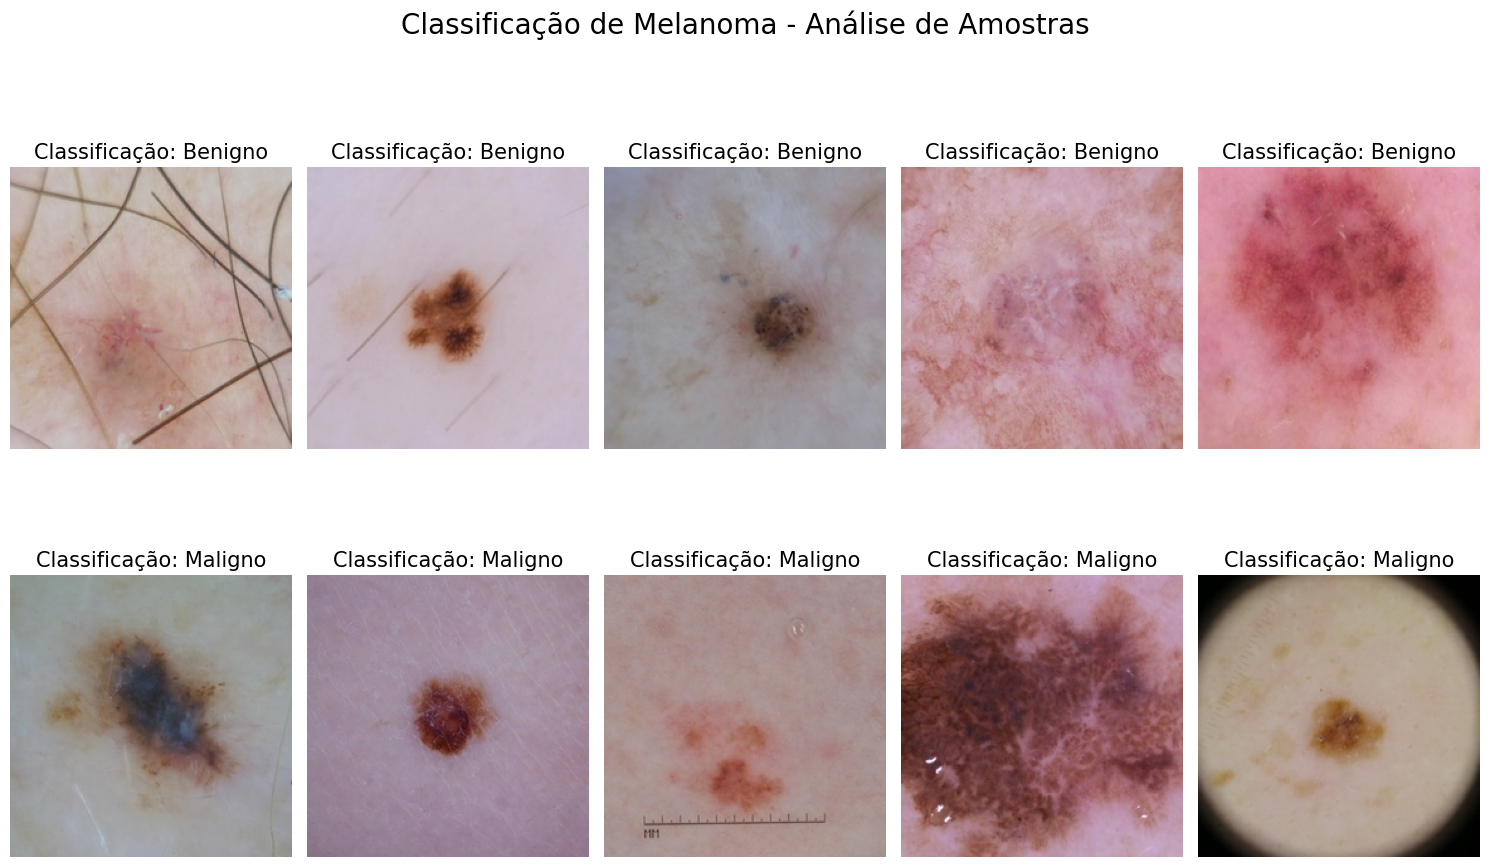

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.suptitle("Classificação de Melanoma - Análise de Amostras", fontsize=20)
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])

    plt.title(f"Classificação: {labels[i]}", fontsize = 15)
    plt.axis('off')

plt.tight_layout()
plt.show()

Podemos realizar algumas análises sobre as imagens dessas amostras:
- A olho nu é praticamente imperceptível a diferença entre amostras malignas ou benignas
- Algumas imagens apresentam diferentes colorações
- Há uma imagem com uma borda preta circular

Isso é um indicador que as imagens devem receber alguns tratamentos afim de normalizar a escala de cor e/ou lidar com bordas

Um histograma de cor pode ser uma boa forma de analisar a distribuição de cores no dataset

In [36]:
histogram_ds = images_ds.batch(512).prefetch(tf.data.AUTOTUNE)
images_tensor, labels_tensor = next(iter(histogram_ds))
images_np = images_tensor.numpy()

In [37]:
def compute_color_histogram(images_np):
    hist_r = np.zeros(256)
    hist_g = np.zeros(256)
    hist_b = np.zeros(256)

    images_255 = (images_np * 255).astype(np.uint8)

    for img in images_255:
        hist_r += np.histogram(img[:, :, 0], bins=256, range=[0, 256])[0]
        hist_g += np.histogram(img[:, :, 1], bins=256, range=[0, 256])[0]
        hist_b += np.histogram(img[:, :, 2], bins=256, range=[0, 256])[0]

    return hist_r, hist_g, hist_b

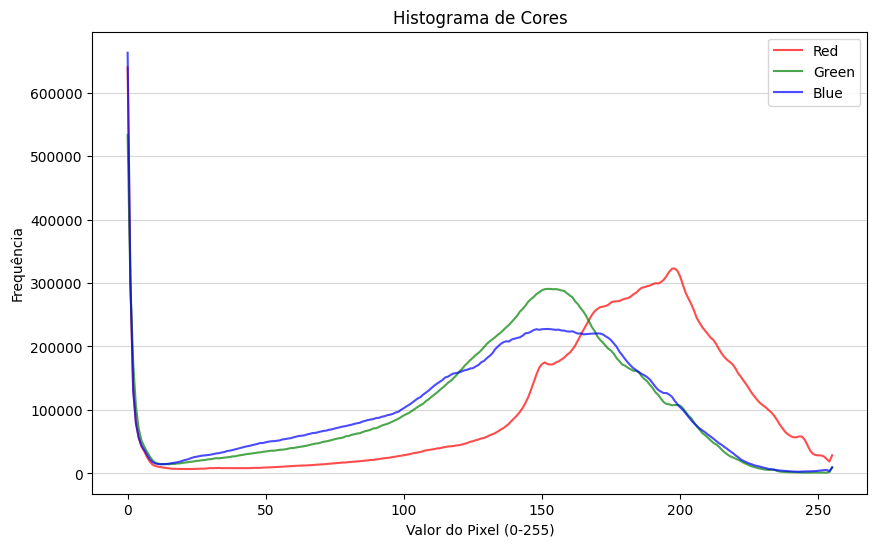

In [38]:
hist_r, hist_g, hist_b = compute_color_histogram(images_np)

plt.figure(figsize=(10, 6))
plt.title("Histograma de Cores")
plt.xlabel("Valor do Pixel (0-255)")
plt.ylabel("Frequência")

plt.plot(hist_r, color='red', alpha=0.7, label='Red')
plt.plot(hist_g, color='green', alpha=0.7, label='Green')
plt.plot(hist_b, color='blue', alpha=0.7, label='Blue')

plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()